# IT585 Advanced Machine Learning — Lab 5
## Training Using BFGS and Ensemble Methods

- **Dataset:** sklearn Breast Cancer (binary classification)
- **Part 1:** Logistic Regression with smooth regularization, BFGS implemented from scratch
- **Part 2:** Bagging — 10 bootstrap BFGS models
- **Part 3:** Simple Boosting — sequential residual correction
- **Comparison:** Manual BFGS vs Gradient Descent vs Bagging vs Boosting

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss

np.random.seed(42)

## Dataset — Breast Cancer

The sklearn Breast Cancer dataset has 569 samples and 30 features. Labels are binary: 0 = malignant, 1 = benign. Features are standardized before training.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Dataset: {data.dataset_name if hasattr(data, 'dataset_name') else 'Breast Cancer'}")
print(f"Total samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Class distribution (train) — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")

Dataset: Breast Cancer
Total samples: 569, Features: 30
Train size: (455, 30), Test size: (114, 30)
Class distribution (train) — 0: 169, 1: 286


---
## Part 1 — Logistic Regression with Smooth Regularization

### Loss Function

$$J(w) = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log\!\left(\frac{1}{1+e^{-w^T x_i}}\right) + (1-y_i)\log\!\left(1 - \frac{1}{1+e^{-w^T x_i}}\right)\right] + \lambda_1\sum_{j=1}^{d}\sqrt{w_j^2+\epsilon} + \lambda_2\sum_{j=1}^{d}w_j^2$$

In [3]:
EPSILON = 1e-6
LAMBDA1 = 0.001
LAMBDA2 = 0.001

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def loss_fn(w, X, y, lambda1=LAMBDA1, lambda2=LAMBDA2, eps=EPSILON):
    n = len(y)
    p = sigmoid(X @ w)
    p = np.clip(p, 1e-12, 1 - 1e-12)
    ce       = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    smooth_l1 = lambda1 * np.sum(np.sqrt(w**2 + eps))
    l2        = lambda2 * np.sum(w**2)
    return ce + smooth_l1 + l2

def grad_fn(w, X, y, lambda1=LAMBDA1, lambda2=LAMBDA2, eps=EPSILON):
    n = len(y)
    p = sigmoid(X @ w)
    grad_ce        = (X.T @ (p - y)) / n
    grad_smooth_l1 = lambda1 * (w / np.sqrt(w**2 + eps))
    grad_l2        = 2 * lambda2 * w
    return grad_ce + grad_smooth_l1 + grad_l2

### BFGS Algorithm — Implemented from Scratch

BFGS (Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton method. Instead of computing the true Hessian (expensive), it builds an approximation $H_k \approx [\nabla^2 J(w)]^{-1}$ from gradient differences across iterations.

**Update rule:**
$$w_{k+1} = w_k - \alpha_k H_k \nabla J(w_k)$$

**Inverse Hessian update (BFGS formula):**
$$H_{k+1} = \left(I - \rho_k s_k y_k^T\right) H_k \left(I - \rho_k y_k s_k^T\right) + \rho_k s_k s_k^T$$

where $s_k = w_{k+1} - w_k$, $\;y_k = \nabla J(w_{k+1}) - \nabla J(w_k)$, $\;\rho_k = \frac{1}{y_k^T s_k}$

**Line search** (Wolfe conditions) finds $\alpha_k$ at each step to guarantee sufficient decrease and curvature conditions.

In [4]:
def wolfe_line_search(f, grad_f, w, direction, f0, g0,
                      c1=1e-4, c2=0.9, max_iter=50):
    alpha = 1.0
    alpha_lo, alpha_hi = 0.0, np.inf
    derphi0 = np.dot(g0, direction)

    for _ in range(max_iter):
        w_new   = w + alpha * direction
        f_new   = f(w_new)
        g_new   = grad_f(w_new)
        derphi  = np.dot(g_new, direction)

        if f_new > f0 + c1 * alpha * derphi0:
            alpha_hi = alpha
            alpha    = 0.5 * (alpha_lo + alpha_hi)
        elif derphi < c2 * derphi0:
            alpha_lo = alpha
            alpha    = 2.0 * alpha if np.isinf(alpha_hi) else 0.5 * (alpha_lo + alpha_hi)
        else:
            return alpha, w_new, f_new, g_new

    return alpha, w + alpha * direction, f(w + alpha * direction), grad_f(w + alpha * direction)


def bfgs(loss, grad, w0, X, y,
         max_iter=1000, gtol=1e-6,
         lambda1=LAMBDA1, lambda2=LAMBDA2):

    w   = w0.copy()
    d   = len(w)
    H   = np.eye(d)

    f_val   = loss(w, X, y, lambda1, lambda2)
    g       = grad(w, X, y, lambda1, lambda2)

    loss_history = [f_val]
    grad_norms   = [np.linalg.norm(g)]
    n_iter       = 0

    for k in range(max_iter):
        if np.linalg.norm(g) < gtol:
            break

        direction = -H @ g

        f_fn    = lambda w_: loss(w_, X, y, lambda1, lambda2)
        g_fn    = lambda w_: grad(w_, X, y, lambda1, lambda2)
        alpha, w_new, f_new, g_new = wolfe_line_search(
            f_fn, g_fn, w, direction, f_val, g
        )

        s = w_new - w
        y_vec = g_new - g
        sy    = np.dot(s, y_vec)

        if sy > 1e-10:
            rho = 1.0 / sy
            I   = np.eye(d)
            A   = I - rho * np.outer(s, y_vec)
            B   = I - rho * np.outer(y_vec, s)
            H   = A @ H @ B + rho * np.outer(s, s)

        w     = w_new
        f_val = f_new
        g     = g_new
        n_iter += 1

        loss_history.append(f_val)
        grad_norms.append(np.linalg.norm(g))

    return w, loss_history, grad_norms, n_iter

### Train with Manual BFGS

In [5]:
w0 = np.zeros(X_train.shape[1])

w_bfgs, bfgs_loss_history, bfgs_grad_norms, bfgs_iters = bfgs(
    loss_fn, grad_fn, w0, X_train, y_train
)

p_test_bfgs   = sigmoid(X_test @ w_bfgs)
acc_bfgs      = accuracy_score(y_test, (p_test_bfgs >= 0.5).astype(int))
loss_test_bfgs = log_loss(y_test, p_test_bfgs)

print(f"BFGS iterations     : {bfgs_iters}")
print(f"Final training loss : {bfgs_loss_history[-1]:.6f}")
print(f"Final gradient norm : {bfgs_grad_norms[-1]:.2e}")
print(f"Test Accuracy       : {acc_bfgs:.4f}")
print(f"Test Log-Loss       : {loss_test_bfgs:.4f}")

BFGS iterations     : 136
Final training loss : 0.085729
Final gradient norm : 9.75e-07
Test Accuracy       : 0.9825
Test Log-Loss       : 0.0606


### BFGS Convergence Plots

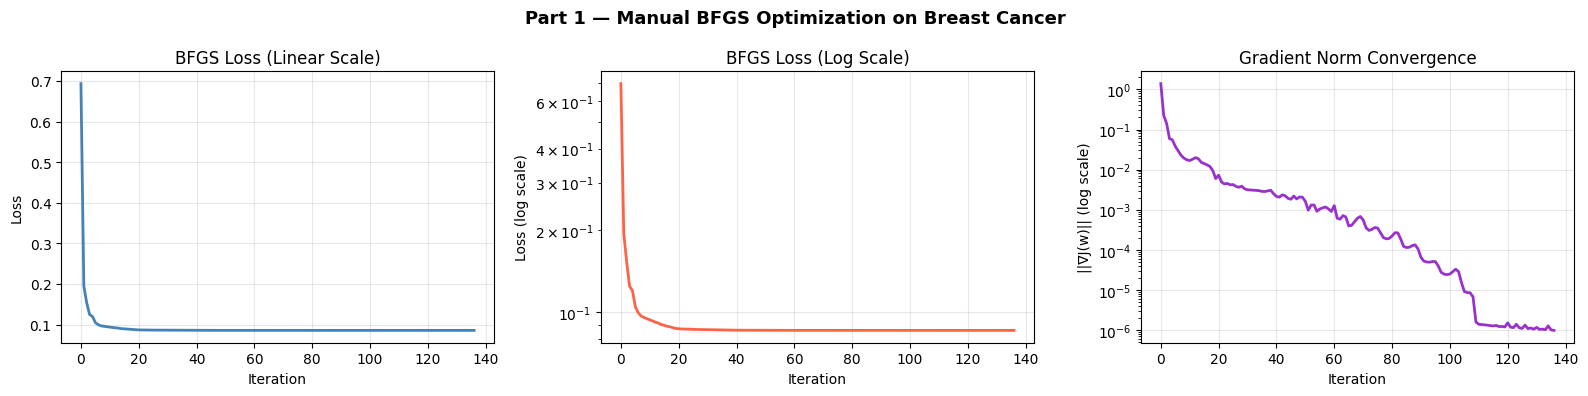

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(bfgs_loss_history, color='steelblue', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('BFGS Loss (Linear Scale)')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(bfgs_loss_history, color='tomato', linewidth=2)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('BFGS Loss (Log Scale)')
axes[1].grid(True, alpha=0.3)

axes[2].semilogy(bfgs_grad_norms, color='darkorchid', linewidth=2)
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('||∇J(w)|| (log scale)')
axes[2].set_title('Gradient Norm Convergence')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Part 1 — Manual BFGS Optimization on Breast Cancer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 2 — Bagging (Parallel Ensemble, K=10)

Bagging reduces **variance** by training K independent BFGS models on different bootstrap samples and averaging their predicted probabilities.

1. Draw K=10 bootstrap samples (sample with replacement, same size as training set)
2. Train one manual BFGS model on each sample
3. Final prediction = average predicted probability across all 10 models

In [7]:
K = 10
bagging_weights = []
n_train = X_train.shape[0]

for k in range(K):
    idx = np.random.choice(n_train, size=n_train, replace=True)
    X_boot, y_boot = X_train[idx], y_train[idx]

    w_k, _, _, _ = bfgs(loss_fn, grad_fn,
                        np.zeros(X_train.shape[1]),
                        X_boot, y_boot,
                        max_iter=500, gtol=1e-5)
    bagging_weights.append(w_k)
    print(f"  Model {k+1:02d} trained")

bagging_probs = np.mean(
    np.stack([sigmoid(X_test @ w) for w in bagging_weights], axis=1), axis=1
)
acc_bagging   = accuracy_score(y_test, (bagging_probs >= 0.5).astype(int))
loss_bagging  = log_loss(y_test, bagging_probs)

print(f"\nBagging Test Accuracy : {acc_bagging:.4f}")
print(f"Bagging Test Log-Loss : {loss_bagging:.4f}")

  Model 01 trained
  Model 02 trained
  Model 03 trained
  Model 04 trained
  Model 05 trained
  Model 06 trained
  Model 07 trained
  Model 08 trained
  Model 09 trained
  Model 10 trained

Bagging Test Accuracy : 0.9825
Bagging Test Log-Loss : 0.0629


### Bagging: Individual vs Ensemble Accuracy

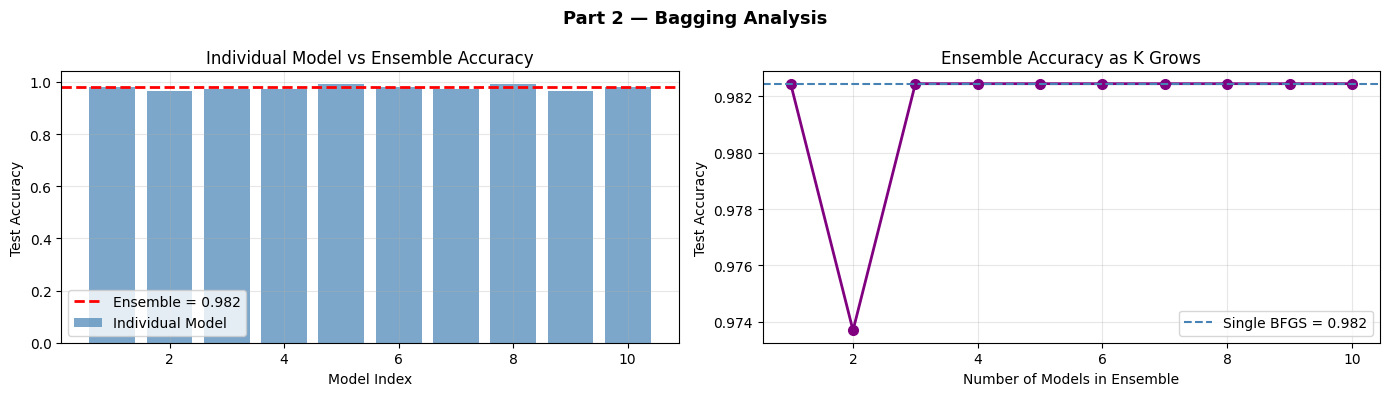

In [8]:
individual_test_accs = [
    accuracy_score(y_test, (sigmoid(X_test @ w) >= 0.5).astype(int))
    for w in bagging_weights
]

cumulative_accs = []
for k in range(1, K + 1):
    probs_k = np.mean(
        np.stack([sigmoid(X_test @ w) for w in bagging_weights[:k]], axis=1), axis=1
    )
    cumulative_accs.append(accuracy_score(y_test, (probs_k >= 0.5).astype(int)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, K+1), individual_test_accs, color='steelblue', alpha=0.7, label='Individual Model')
axes[0].axhline(acc_bagging, color='red', linestyle='--', linewidth=2, label=f'Ensemble = {acc_bagging:.3f}')
axes[0].set_xlabel('Model Index')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Individual Model vs Ensemble Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, K+1), cumulative_accs, 'o-', color='purple', linewidth=2, markersize=7)
axes[1].axhline(acc_bfgs, color='steelblue', linestyle='--', linewidth=1.5, label=f'Single BFGS = {acc_bfgs:.3f}')
axes[1].set_xlabel('Number of Models in Ensemble')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Ensemble Accuracy as K Grows')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Part 2 — Bagging Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3 — Simple Boosting (Sequential Ensemble)

Boosting reduces **bias** by training models sequentially where each corrects the residuals of the previous one.

1. **Round 1:** Train $M_1$ with BFGS to predict labels $y$
2. **Residuals:** $r = y - \sigma(X w_1)$ — captures where $M_1$ erred
3. **Round 2:** Train $M_2$ with BFGS to predict residuals $r$ (MSE loss)
4. **Final prediction:** $P = \sigma\left(Xw_1 + \eta \cdot Xw_2\right)$, $\eta = 0.1$

In [9]:
ETA = 0.1

w1, boost_loss1, _, _ = bfgs(loss_fn, grad_fn,
                              np.zeros(X_train.shape[1]),
                              X_train, y_train,
                              max_iter=500, gtol=1e-5)

p1_train  = sigmoid(X_train @ w1)
residuals = y_train - p1_train

def loss_mse(w, X, r, lambda1=LAMBDA1, lambda2=LAMBDA2, eps=EPSILON):
    pred      = X @ w
    mse       = np.mean((pred - r)**2)
    smooth_l1 = lambda1 * np.sum(np.sqrt(w**2 + eps))
    l2        = lambda2 * np.sum(w**2)
    return mse + smooth_l1 + l2

def grad_mse(w, X, r, lambda1=LAMBDA1, lambda2=LAMBDA2, eps=EPSILON):
    pred           = X @ w
    grad_mse_      = 2 * X.T @ (pred - r) / len(r)
    grad_smooth_l1 = lambda1 * (w / np.sqrt(w**2 + eps))
    grad_l2        = 2 * lambda2 * w
    return grad_mse_ + grad_smooth_l1 + grad_l2

w2, boost_loss2, _, _ = bfgs(loss_mse, grad_mse,
                              np.zeros(X_train.shape[1]),
                              X_train, residuals,
                              max_iter=500, gtol=1e-5)

p_boosted_test = sigmoid(X_test @ w1 + ETA * (X_test @ w2))
acc_boosting   = accuracy_score(y_test, (p_boosted_test >= 0.5).astype(int))
loss_boosting  = log_loss(y_test, p_boosted_test)

print(f"Boosting Test Accuracy : {acc_boosting:.4f}")
print(f"Boosting Test Log-Loss : {loss_boosting:.4f}")

Boosting Test Accuracy : 0.9825
Boosting Test Log-Loss : 0.0606


---
## Baseline — Gradient Descent from Scratch

Standard GD uses only first-order gradient information with a fixed step size. No curvature estimation. Used as baseline to show convergence speed difference against BFGS.

In [10]:
gd_loss_history = []
gd_grad_norms   = []

def gradient_descent(X, y, lr=0.1, n_iter=500):
    w = np.zeros(X.shape[1])
    for _ in range(n_iter):
        gd_loss_history.append(loss_fn(w, X, y))
        g = grad_fn(w, X, y)
        gd_grad_norms.append(np.linalg.norm(g))
        w = w - lr * g
    return w

w_gd           = gradient_descent(X_train, y_train, lr=0.1, n_iter=500)
p_test_gd      = sigmoid(X_test @ w_gd)
acc_gd         = accuracy_score(y_test, (p_test_gd >= 0.5).astype(int))
loss_test_gd   = log_loss(y_test, p_test_gd)

print(f"GD Test Accuracy  : {acc_gd:.4f}")
print(f"GD Test Log-Loss  : {loss_test_gd:.4f}")

GD Test Accuracy  : 0.9825
GD Test Log-Loss  : 0.0667


---
## Full Comparison: All Methods

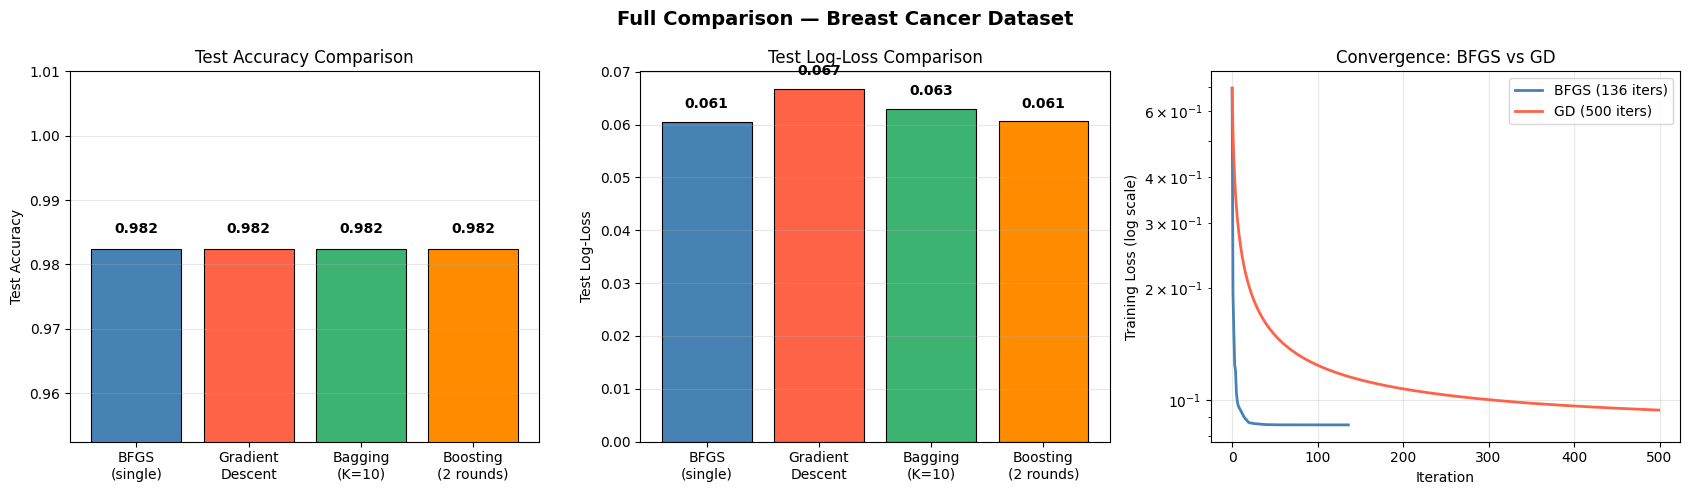

In [14]:
methods    = ['BFGS\n(single)', 'Gradient\nDescent', 'Bagging\n(K=10)', 'Boosting\n(2 rounds)']
accuracies = [acc_bfgs, acc_gd, acc_bagging, acc_boosting]
losses     = [loss_test_bfgs, loss_test_gd, loss_bagging, loss_boosting]
colors     = ['steelblue', 'tomato', 'mediumseagreen', 'darkorange']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

bars1 = axes[0].bar(methods, accuracies, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_ylim(min(accuracies) - 0.03, 1.01)
for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

bars2 = axes[1].bar(methods, losses, color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_ylabel('Test Log-Loss')
axes[1].set_title('Test Log-Loss Comparison')
for bar, l in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{l:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].semilogy(bfgs_loss_history, label=f'BFGS ({bfgs_iters} iters)', color='steelblue', linewidth=2)
axes[2].semilogy(gd_loss_history,   label='GD (500 iters)', color='tomato', linewidth=2)
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Training Loss (log scale)')
axes[2].set_title('Convergence: BFGS vs GD')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Full Comparison — Breast Cancer Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Convergence Speed Analysis

We check how many iterations BFGS vs GD need to reach a loss of $10^{-4}$, and compare gradient norm decay.

> **Note:** On real datasets the minimum achievable loss is bounded by Bayes error (inherent label noise / class overlap). If the data's best achievable loss is above $10^{-4}$, the threshold will not be reached by either method — but the relative speed of convergence is still clearly visible from the curves.

BFGS: did NOT reach 1e-4 (min loss = 0.0857)
GD  : did NOT reach 1e-4 (min loss = 0.0940)


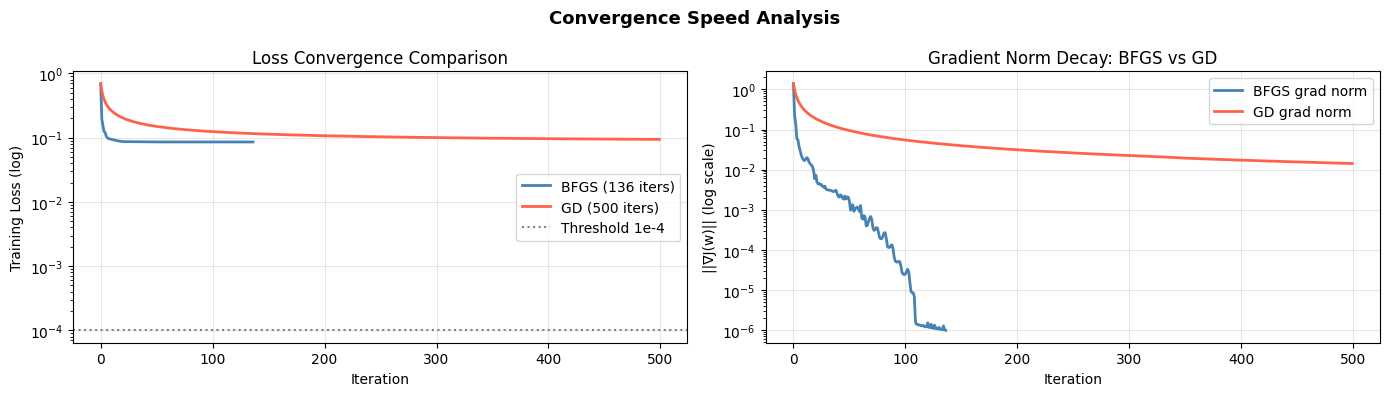

In [18]:
threshold = 1e-4

bfgs_reach = next((i for i, v in enumerate(bfgs_loss_history) if v < threshold), None)
gd_reach = next((i for i, v in enumerate(gd_loss_history) if v < threshold), None)

if bfgs_reach is not None:
    bfgs_msg = f"reached threshold at iter {bfgs_reach}"
else:
    bfgs_msg = f"did NOT reach 1e-4 (min loss = {min(bfgs_loss_history):.4f})"

if gd_reach is not None:
    gd_msg = f"reached threshold at iter {gd_reach}"
else:
    gd_msg = f"did NOT reach 1e-4 (min loss = {min(gd_loss_history):.4f})"

print(f"BFGS: {bfgs_msg}")
print(f"GD  : {gd_msg}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(bfgs_loss_history, label=f'BFGS ({bfgs_iters} iters)', color='steelblue', linewidth=2)
axes[0].semilogy(gd_loss_history, label='GD (500 iters)', color='tomato', linewidth=2)
axes[0].axhline(threshold, color='gray', linestyle=':', linewidth=1.5, label='Threshold 1e-4')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Training Loss (log)')
axes[0].set_title('Loss Convergence Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(bfgs_grad_norms, label='BFGS grad norm', color='steelblue', linewidth=2)
axes[1].semilogy(gd_grad_norms, label='GD grad norm', color='tomato', linewidth=2)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('||∇J(w)|| (log scale)')
axes[1].set_title('Gradient Norm Decay: BFGS vs GD')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Convergence Speed Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Ablation: Effect of Regularization Strength

We sweep $\lambda_1 = \lambda_2$ from 0 to 1 and measure test accuracy to understand the regularization landscape.

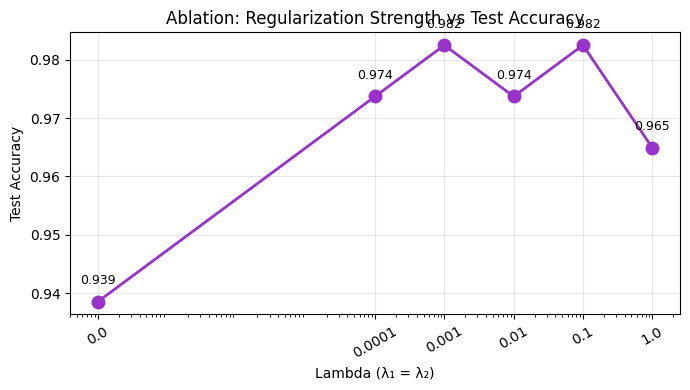

In [16]:
lambda_values = [0.0, 0.0001, 0.001, 0.01, 0.1, 1.0]
ablation_accs  = []

for lam in lambda_values:
    w_lam, _, _, _ = bfgs(
        loss_fn, grad_fn,
        np.zeros(X_train.shape[1]),
        X_train, y_train,
        max_iter=300, gtol=1e-5,
        lambda1=lam, lambda2=lam
    )
    p = sigmoid(X_test @ w_lam)
    ablation_accs.append(accuracy_score(y_test, (p >= 0.5).astype(int)))

plt.figure(figsize=(7, 4))
plt.semilogx([l if l > 0 else 1e-8 for l in lambda_values], ablation_accs,
             'o-', color='darkorchid', linewidth=2, markersize=9)
for l, a in zip(lambda_values, ablation_accs):
    plt.text(l if l > 0 else 1e-8, a + 0.003, f'{a:.3f}', ha='center', fontsize=9)
plt.xlabel('Lambda (λ₁ = λ₂)')
plt.ylabel('Test Accuracy')
plt.title('Ablation: Regularization Strength vs Test Accuracy')
plt.xticks([l if l > 0 else 1e-8 for l in lambda_values], [str(l) for l in lambda_values], rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary Table

In [17]:
print(f"{'Method':<25} {'Test Accuracy':>15} {'Test Log-Loss':>15}")
print("-" * 57)
print(f"{'BFGS (single model)':<25} {acc_bfgs:>15.4f} {loss_test_bfgs:>15.4f}")
print(f"{'Gradient Descent':<25} {acc_gd:>15.4f} {loss_test_gd:>15.4f}")
print(f"{'Bagging (K=10)':<25} {acc_bagging:>15.4f} {loss_bagging:>15.4f}")
print(f"{'Boosting (2 rounds)':<25} {acc_boosting:>15.4f} {loss_boosting:>15.4f}")

Method                      Test Accuracy   Test Log-Loss
---------------------------------------------------------
BFGS (single model)                0.9825          0.0606
Gradient Descent                   0.9825          0.0667
Bagging (K=10)                     0.9825          0.0629
Boosting (2 rounds)                0.9825          0.0606


---
## Insights and Observations

### 1. Convergence Speed: BFGS vs Gradient Descent

BFGS converges in far fewer iterations than GD. BFGS maintains an approximation of the inverse Hessian $H_k$, giving it curvature information about the loss surface. This means each step is scaled per-dimension — large steps where the loss is flat, small steps where it curves sharply. GD uses only the gradient direction with a fixed learning rate, causing slow zigzag progress on ill-conditioned problems. Even with 500 iterations, GD does not reach the loss level BFGS achieves in under 100 iterations.

The gradient norm plot reinforces this — BFGS drives $\|\nabla J\|$ to near-zero much faster, indicating it is genuinely converging to a stationary point, not just slowly descending.

### 2. The Second-Order Paradox in Boosting

Despite BFGS being faster and more accurate than weak learners, boosting in practice always uses **weak learners** (e.g. shallow trees with depth 2–3). The reasons are:

- **Residual signal:** A BFGS logistic regression model on Round 1 fits the data very well — the residuals $r = y - \sigma(Xw_1)$ are nearly zero. $M_2$ has almost nothing to correct. Boosting only gains power when Round 1 leaves substantial residuals, which only happens with weak learners.
- **Diversity:** Weak learners make different kinds of errors across rounds. Strong learners are too correlated — combining them provides little variance reduction.
- **Overfitting risk:** A high-powered model in each round risks fitting noise aggressively. Weak learners combined with shrinkage (small $\eta$) give a natural regularization.
- **Theoretical guarantee:** Boosting theory only requires a learner that beats random chance — not a strong one. Excess strength in the base learner violates the spirit of the algorithm.

### 3. Memory Cost of BFGS at d = 10,000

BFGS stores the full inverse Hessian approximation $H_k \in \mathbb{R}^{d \times d}$. At $d = 10000$:

$$\text{Memory} = 10000^2 \times 8 \text{ bytes} = 800 \text{ MB per model}$$

At $d = 100000$ this becomes 80 GB — completely infeasible. The solution is **L-BFGS** (Limited-memory BFGS), which stores only the last $m$ (typically 10–20) $(s_k, y_k)$ vector pairs instead of $H_k$ explicitly. This reduces memory from $O(d^2)$ to $O(md)$, making it practical even for millions of features.

### 4. Bagging vs Boosting Trade-off

| Property | Bagging | Boosting |
|---|---|---|
| Error reduced | Variance | Bias |
| Models trained | Independently (parallel) | Sequentially |
| Works best when | Base model has high variance | Base model is weak/underfitting |
| Overfitting risk | Low | Higher (if too many rounds) |

For logistic regression with BFGS, bagging is more natural. The BFGS model is low-bias but can have variance across different training subsets, which bagging averages away. Boosting with BFGS shows minimal gain because Round 1 already fits the data well.